# Ensemble and 70% Confidence Interval (validation only)

This notebook blends the two models of `03_ky_modelling_xgboost_lightgbm` (XGBoost and LightGBM), builds a **70% interval whose width depends on N**, and checks how often the true total falls inside that interval. The approach is called method A: the models are fitted on train, and the blend weight and the margins are tuned on validation, with **no out-of-fold (OOF) predictions**. **The test set is not used in this notebook** because it never loads the test rows. The weight and the margins are frozen here and evaluated on the test set once, in `05_ky_test_evaluation`.

**Data:** The notebook uses the classification model's train, validation and test property split from `02_ky_data_preparation`, with baskets of N = 10, 20, 30 and 50 and vehicles excluded. All numbers are in dollars.

## Method A and why

| Data | Regression models | Classification model (`03_fm_modelling`) |
|---|---|---|
| **train** | Fits the models (`03_ky_modelling_xgboost_lightgbm`) | Fits the models. Its K-fold (`GroupKFold(5)`) sits **inside train** only, for tuning |
| **validation** | Tunes and selects only: the hyperparameters and number of trees (`03_ky_modelling_xgboost_lightgbm`) and the **blend weight and margins (this notebook)**. Never fitted on | Compares and selects models. Never fitted on |
| **test** | Not used here (`05_ky_test_evaluation` evaluates the frozen weight and margins once) | Scored once |

1. **Why validation, not the training set, sets the weight and margins.** The models were fitted on the training rows, so their training predictions are already "seen" (in-sample) and the errors are too small. The section *Why not the training set* shows that the training margins are clearly narrower than the validation margins, so intervals built from them would cover much less than 70% on new homes.
2. **Why not method B (pooling train and validation and making OOF predictions).** With OOF predictions no household is predicted by a model that saw it, so there is no direct leakage. However, the regression would then **learn from the validation households** (the other ones), which breaks the rule of the classification model that validation is used for tuning and checking only and never for learning. Method B would also replace the validation set by K-fold for tuning, which is not how the classification model works. Method A keeps the same division of work in both models.
3. **No OOF and no cross-fitting here.** Because the margins are learned on the validation rows, the success rate measured on those same rows is **in-sample** and is **not a result**. The result is the test success rate with the frozen margins, which is evaluated in `05_ky_test_evaluation`.
4. **The validation set is small.** It has 18 properties and 230 rows, with only 9 and 6 properties at N = 30 and N = 50, so the margins are noisy, especially for those two baskets. **Each N keeps its own margin**, which means that N = 10, 20, 30 and 50 are separate groups. The section on margins shows a bootstrap by property (resampling households) so that the uncertainty of each margin is visible. A switch `POOL_N30_N50` in the setup cell would pool N = 30 and N = 50 into one group, and it is switched off.
5. **Use for the classification model.** This notebook is a regression result only. The saved models, the blend weight and the margins can be applied to the households of the classification model as extra features, without any further training.
6. **Validation is used several times.** In `03_ky_modelling_xgboost_lightgbm` it chooses the hyperparameters and the number of trees, here it chooses the blend weight and the margins, and the classification model uses it for its own choices, so validation numbers are optimistic. Conclusions should rely on the **test** set, which has only 13 properties and no very large home, so it is noisy too.
7. **The test set is not touched here.** The interval is evaluated on it once, in `05_ky_test_evaluation`, with the weight and margins frozen here. The test set was seen while the notebooks were being developed, so it is not an untouched holdout for the whole project.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.spines.top": False, "axes.spines.right": False})
from sklearn.metrics import mean_absolute_error

PROCESSED = Path("../../data/processed/regression")     # modelling tables from 02_ky_data_preparation
INTERIM = Path("../../data/interim/regression")
MODELS = Path("../../models/regression")
CONFIDENCE = 0.70
POOL_N30_N50 = False           # False keeps one margin per N, True would pool N = 30 and N = 50

preds = pd.read_parquet(INTERIM / "tuned_model_predictions.parquet")      # written by 03_ky_modelling_xgboost_lightgbm: models fitted on TRAIN only
val_df = pd.read_parquet(PROCESSED / "val_df.parquet")
val = preds[preds["split"] == "val"].reset_index(drop=True)          # validation rows only: the test rows of the file are not used in this notebook
# the prediction table was built in the row order of val_df: attach the documented value of the basket
assert (val["Property_ID"].values == val_df["Property_ID"].values).all() and (val["n_documented"].values == val_df["n_documented"].values).all()
val["documented_value"] = val_df["sum_value"].values

def wape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return 100.0 * np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

def group_of(n):
    n = np.asarray(n)
    if POOL_N30_N50:
        return np.where(n == 10, "N=10", np.where(n == 20, "N=20", "N=30+50"))
    return np.array([f"N={int(k)}" for k in n])

print(f"validation: {len(val)} rows / {val['Property_ID'].nunique()} properties (the test set is not used in this notebook)")
print("margin groups:", [str(g) for g in sorted(set(group_of(val['n_documented'])))])

validation: 230 rows / 18 properties (the test set is not used in this notebook)
margin groups: ['N=10', 'N=20', 'N=30', 'N=50']


## Step 1 — Compare the two models and choose the blend weight on the validation set

The ensemble is `w x XGBoost + (1 - w) x LightGBM`. The weight `w` ranges from 0.00 to 1.00 in **steps of 0.02**, and the chosen value is the one with the lowest **validation** MAE. A finer grid cannot add real information, because the curve is flat around its minimum and the exact weight is therefore not sharply determined. The two models were fitted on train only, so their validation predictions are out-of-sample. A weight of `w = 0` simply means that only LightGBM is used.

**Training curve (diagnostic only).** The chart also shows the same curve on the **training rows**. Those predictions are in-sample because the models were fitted on them, so the training curve is **not** used to choose the weight. It is shown to help read the fit. A training error far below the validation error means **overfitting**, while a training error that is also high or close to the validation error means that the models are not flexible enough (**underfitting**) or that most of the error is noise the models cannot explain.

best blend weight (XGBoost share): 0.28 | validation MAE $36,514
XGBoost alone (w=1): $37,535 | LightGBM alone (w=0): $36,793 | 50/50: $36,565
the 6 weights with the lowest validation MAE: {0.28: 36514, 0.26: 36515, 0.3: 36515, 0.24: 36516, 0.22: 36518, 0.32: 36518}
weights within $100 of the best: [0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56]


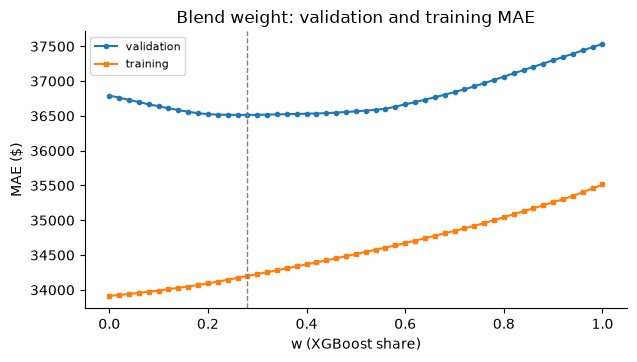

MAE in dollars, training (in-sample) vs validation:


,training MAE,validation MAE,validation - training
LightGBM alone (w = 0),33914.0,36793.0,2879.0
ensemble (w = 0.28),34200.0,36514.0,2314.0
XGBoost alone (w = 1),35515.0,37535.0,2020.0


the weight with the lowest TRAINING MAE would be 0.00. The weight chosen on validation is 0.28 (the training curve plays no part in the choice)
typical (median) absolute error at w = 0.28: training $3,473 vs validation $16,837. The mean (MAE) gap is small because one very large home ($1.35M) in train dominates the training mean


,validation MAE,validation WAPE %
XGBoost,37534.5,49.9
LightGBM,36793.0,48.9
Ensemble (w = 0.28),36514.0,48.5


In [2]:
ws = np.round(np.arange(0, 1.0001, 0.02), 2)
curve = pd.Series([mean_absolute_error(val["true_total_value"], w * val["xgb_tuned_pred"] + (1 - w) * val["lgbm_tuned_pred"]) for w in ws], index=ws, name="validation MAE")
best_w = float(curve.idxmin())
print(f"best blend weight (XGBoost share): {best_w:.2f} | validation MAE ${curve.min():,.0f}")
print(f"XGBoost alone (w=1): ${curve.loc[1.0]:,.0f} | LightGBM alone (w=0): ${curve.loc[0.0]:,.0f} | 50/50: ${curve.loc[0.5]:,.0f}")
print("the 6 weights with the lowest validation MAE:", {float(w): round(float(m)) for w, m in curve.nsmallest(6).items()})
print("weights within $100 of the best:", [float(w) for w in curve.index[curve <= curve.min() + 100]])
# ---- training curve (in-sample, diagnostic only): predictions of the same two models on the TRAIN rows
import joblib
train_df = pd.read_parquet(PROCESSED / "train_df.parquet")
FEATURE_COLS = [c for c in train_df.columns if c not in ("Property_ID", "true_total_value")]
mx, ml = joblib.load(MODELS / "xgb_log_model.joblib"), joblib.load(MODELS / "lgbm_log_model.joblib")
tr_x, tr_l = np.expm1(mx.predict(train_df[FEATURE_COLS])), np.expm1(ml.predict(train_df[FEATURE_COLS]))
y_tr = train_df["true_total_value"].values
train_curve = pd.Series([mean_absolute_error(y_tr, w * tr_x + (1 - w) * tr_l) for w in ws], index=ws, name="training MAE")

fig, ax = plt.subplots()
ax.plot(curve.index, curve.values, marker="o", ms=3, label="validation")
ax.plot(train_curve.index, train_curve.values, marker="s", ms=3, label="training")
ax.axvline(best_w, color="grey", ls="--", lw=1)
ax.set_xlabel("w (XGBoost share)")
ax.set_ylabel("MAE ($)")
ax.set_title("Blend weight: validation and training MAE")
ax.legend(fontsize=8)
plt.show()

gap = pd.DataFrame({"training MAE": [train_curve.loc[0.0], train_curve.loc[best_w], train_curve.loc[1.0]], "validation MAE": [curve.loc[0.0], curve.loc[best_w], curve.loc[1.0]]},
                   index=["LightGBM alone (w = 0)", f"ensemble (w = {best_w:.2f})", "XGBoost alone (w = 1)"])
gap["validation - training"] = gap["validation MAE"] - gap["training MAE"]
print("MAE in dollars, training (in-sample) vs validation:")
display(gap.round(0))
med_tr = np.median(np.abs(y_tr - (best_w * tr_x + (1 - best_w) * tr_l)))
med_va = np.median(np.abs(val["true_total_value"].values - (best_w * val["xgb_tuned_pred"].values + (1 - best_w) * val["lgbm_tuned_pred"].values)))
print(f"the weight with the lowest TRAINING MAE would be {float(train_curve.idxmin()):.2f}. The weight chosen on validation is {best_w:.2f} (the training curve plays no part in the choice)")
print(f"typical (median) absolute error at w = {best_w:.2f}: training ${med_tr:,.0f} vs validation ${med_va:,.0f}. The mean (MAE) gap is small because one very large home ($1.35M) in train dominates the training mean")

val["ensemble_pred"] = best_w * val["xgb_tuned_pred"] + (1 - best_w) * val["lgbm_tuned_pred"]
pd.DataFrame({m: {"validation MAE": mean_absolute_error(val["true_total_value"], val[c]), "validation WAPE %": wape(val["true_total_value"], val[c])}
              for m, c in [("XGBoost", "xgb_tuned_pred"), ("LightGBM", "lgbm_tuned_pred"), (f"Ensemble (w = {best_w:.2f})", "ensemble_pred")]}).T.round(1)

### Why the weight is chosen on validation, and why not w = 0

The blend weight is chosen on the validation set and not on the training set. The two models were fitted on the training rows, so their training predictions are in-sample. The training error is lowest for LightGBM alone (w = 0) simply because LightGBM fits the training homes best, which says nothing about new homes. The validation homes were not used to fit the models, so the validation error is an out-of-sample estimate. It is lowest at w = 0.28 (MAE $36,514), only $279 below LightGBM alone ($36,793). That difference is inside the noise of 18 validation properties, and every weight between 0.12 and 0.56 is within $100 of the best, so the data does not rule out w = 0. We keep the weight selected by the pre-agreed rule (lowest validation MAE) so that both models contribute, which also averages out part of the seed-to-seed variation between the two models. We do not claim that the blend is reliably better than LightGBM alone.

## Step 2 — The margin of each N group, learned on the validation set

For every validation row the **relative residual** is `|true - prediction| / prediction`. The margin of a group is the **70th percentile** of that group's relative residuals, and the interval is `prediction x (1 +/- margin)`. A row of N items only ever uses the margin of its own group.

The table shows both the single-N margins and the margins of the groups used. The bootstrap columns resample the **properties** (households) 500 times to show how uncertain each margin is with only 18 validation properties, and the range is widest for N = 30 and N = 50.

In [3]:
val["rel_resid"] = (val["true_total_value"] - val["ensemble_pred"]).abs() / val["ensemble_pred"].clip(lower=1)
rng = np.random.default_rng(42)

def margin_table(df, groups):
    rows = []
    for g in sorted(set(groups)):
        m = groups == g
        sub = df[m]
        props = sub["Property_ID"].unique()
        by_prop = {p: sub.loc[sub["Property_ID"] == p, "rel_resid"].values for p in props}
        boots = [np.quantile(np.concatenate([by_prop[p] for p in rng.choice(props, len(props))]), CONFIDENCE) for _ in range(500)]
        rows.append({"group": g, "rows": int(m.sum()), "properties": len(props), "margin (70th pct)": np.quantile(sub["rel_resid"], CONFIDENCE),
                     "bootstrap 5%": np.quantile(boots, 0.05), "bootstrap 95%": np.quantile(boots, 0.95)})
    return pd.DataFrame(rows).set_index("group")

single = margin_table(val, np.array([f"N={int(k)}" for k in val["n_documented"]]))
print("margins with one group per N (reference):")
display(single.round(2))
val["group"] = group_of(val["n_documented"])
margins = margin_table(val, val["group"].values)
print("margins of the groups used:", "N=30 and N=50 pooled" if POOL_N30_N50 else "one margin per N")
display(margins.round(2))
MARGIN = margins["margin (70th pct)"].to_dict()      # frozen from here on
MARGIN

margins with one group per N (reference):


,rows,properties,margin (70th pct),bootstrap 5%,bootstrap 95%
group,,,,,
N=10,90,18,0.83,0.57,1.12
N=20,65,13,0.51,0.37,0.89
N=30,45,9,0.43,0.24,0.90
N=50,30,6,0.59,0.11,0.90


margins of the groups used: one margin per N


,rows,properties,margin (70th pct),bootstrap 5%,bootstrap 95%
group,,,,,
N=10,90,18,0.83,0.58,1.01
N=20,65,13,0.51,0.38,0.89
N=30,45,9,0.43,0.24,0.90
N=50,30,6,0.59,0.09,0.90


{'N=10': 0.827846991853316,
 'N=20': 0.5110750644087545,
 'N=30': 0.4257845048740497,
 'N=50': 0.5903092261343441}

## Why not the training set? (the margins the same models would give on their own training rows)

The two models were fitted on the training rows, so those predictions are in-sample. The table compares the margin from the training rows with the margin from the validation rows (same weight, same groups). This is the evidence for using validation, and it is also why a margin learned on training rows would give intervals that are too narrow.

In [4]:
import joblib
train_df = pd.read_parquet(PROCESSED / "train_df.parquet")
FEATURE_COLS = [c for c in train_df.columns if c not in ("Property_ID", "true_total_value")]
mx, ml = joblib.load(MODELS / "xgb_log_model.joblib"), joblib.load(MODELS / "lgbm_log_model.joblib")
tr = train_df[["Property_ID", "n_documented", "true_total_value"]].copy()
tr["ensemble_pred"] = best_w * np.expm1(mx.predict(train_df[FEATURE_COLS])) + (1 - best_w) * np.expm1(ml.predict(train_df[FEATURE_COLS]))
tr["rel_resid"] = (tr["true_total_value"] - tr["ensemble_pred"]).abs() / tr["ensemble_pred"].clip(lower=1)
tr["group"] = group_of(tr["n_documented"])
cmp_ = pd.DataFrame({"train rows": tr.groupby("group").size(), "train margin (in-sample)": tr.groupby("group")["rel_resid"].quantile(CONFIDENCE),
                     "validation rows": val.groupby("group").size(), "validation margin": val.groupby("group")["rel_resid"].quantile(CONFIDENCE)})
display(cmp_.round(2))
print("training MAE $%s (the training set contains the largest home, $1.35M) vs validation MAE $%s" % (
    f"{mean_absolute_error(tr['true_total_value'], tr['ensemble_pred']):,.0f}", f"{mean_absolute_error(val['true_total_value'], val['ensemble_pred']):,.0f}"))

,train rows,train margin (in-sample),validation rows,validation margin
group,,,,
N=10,405,0.42,90,0.83
N=20,285,0.19,65,0.51
N=30,210,0.16,45,0.43
N=50,130,0.06,30,0.59


training MAE $34,200 (the training set contains the largest home, $1.35M) vs validation MAE $36,514


## Step 3 — The 70% interval on the validation set (in-sample: NOT a result)

For every row, `lower = prediction x (1 - margin)` and `upper = prediction x (1 + margin)`, with the margin of the row's own group. A row is a **success** when the true total value is inside `[lower, upper]`.

- **Row-level success rate:** The number of hit rows divided by the number of all rows.
- **Household-level success rate:** The average of each household's own hit rate, so that every household counts once, reported with a standard error over households. For example, a household with 4 rows of which 3 are hits has a household hit rate of 0.75, and two households with rates of 0.75 and 1.00 give a household-level rate of 0.875.
- **Floor at the documented value:** The true total can never be below the value already documented in the basket (`sum_value`), so `lower_floor = max(lower, documented value)`. This never removes a hit and only narrows the interval, and both widths are shown.

These validation rates are **in-sample** because the margins were learned on the same rows, so they sit near 70% by construction and say nothing about new homes.

In [5]:
def add_interval(df):
    df = df.copy()
    df["margin"] = df["group"].map(MARGIN)
    df["lower"] = df["ensemble_pred"] * (1 - df["margin"])
    df["upper"] = df["ensemble_pred"] * (1 + df["margin"])
    df["lower_floor"] = np.maximum(df["lower"], df["documented_value"])
    df["hit"] = (df["true_total_value"] >= df["lower"]) & (df["true_total_value"] <= df["upper"])
    df["hit_floor"] = (df["true_total_value"] >= df["lower_floor"]) & (df["true_total_value"] <= df["upper"])
    df["above"] = df["true_total_value"] > df["upper"]
    df["below"] = df["true_total_value"] < df["lower"]
    df["width"], df["width_floor"] = df["upper"] - df["lower"], df["upper"] - df["lower_floor"]
    return df

def summarise(df):
    def one(g):
        hh = g.groupby("Property_ID")["hit"].mean()
        return pd.Series({"rows": len(g), "households": g["Property_ID"].nunique(),
                          "row success %": 100 * g["hit"].mean(), "household success %": 100 * hh.mean(),
                          "household SE (pts)": 100 * hh.std(ddof=1) / np.sqrt(len(hh)) if len(hh) > 1 else np.nan,
                          "above band": int(g["above"].sum()), "below band": int(g["below"].sum()),
                          "median width ($)": g["width"].median(), "median width with floor ($)": g["width_floor"].median(),
                          "hits lost by floor": int((g["hit"] & ~g["hit_floor"]).sum())})
    out = df.groupby("group").apply(one)
    out.loc["ALL"] = one(df)
    return out

val_i = add_interval(val)
display(summarise(val_i).round(1))

,rows,households,row success %,household success %,household SE (pts),above band,below band,median width ($),median width with floor ($),hits lost by floor
group,,,,,,,,,,
N=10,90.0,18.0,73.3,73.3,9.0,19.0,5.0,52761.3,47207.6,0.0
N=20,65.0,13.0,67.7,67.7,11.4,9.0,12.0,51249.7,44062.8,0.0
N=30,45.0,9.0,68.9,68.9,14.6,6.0,8.0,52644.9,46576.0,0.0
N=50,30.0,6.0,70.0,70.0,19.1,4.0,5.0,81929.1,60455.6,0.0
ALL,230.0,18.0,70.4,77.8,7.2,38.0,30.0,52760.3,47207.6,0.0


## Success rate per N: train rows and validation rows, side by side

The same frozen margins are applied to the **train rows** and to the **validation rows**, one row at a time, and the success rate is counted per N at row level. Both rates are in-sample, in different ways, so **neither is a result**:
- **Validation rows:** They set the margins, so their rate sits near 70% by construction.
- **Train rows:** They were used to fit the two models, so the predictions are better than they would be on new homes, while the margins come from the validation rows.

The last columns are diagnostics only. They show the margin that would give exactly 70% on that set (the 70th percentile of the relative error) and `pred / true`, which is the sum of the predictions divided by the sum of the true values, where a value below 1 means that the models under-predict on average.

,frozen margin (%),train rows,train success (%),validation rows,"validation success, in-sample (%)",train 70th-pct relative error (%),validation 70th-pct relative error (%),train pred / true,validation pred / true
N documented,,,,,,,,,
N=10,82.78,405.0,91.11,90.0,73.33,42.01,82.78,0.69,0.65
N=20,51.11,285.0,86.67,65.0,67.69,18.93,51.11,0.68,0.80
N=30,42.58,210.0,88.57,45.0,68.89,15.94,42.58,0.74,0.80
N=50,59.03,130.0,91.54,30.0,70.00,6.33,59.03,0.83,0.82
ALL,NaN,1030.0,89.42,230.0,70.43,23.87,68.67,0.72,0.76


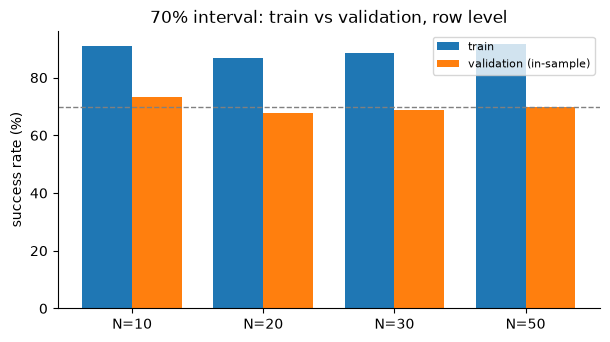

In [6]:
tr["margin"] = tr["group"].map(MARGIN)
tr["hit"] = (tr["true_total_value"] >= tr["ensemble_pred"] * (1 - tr["margin"])) & (tr["true_total_value"] <= tr["ensemble_pred"] * (1 + tr["margin"]))
tr["above"], tr["below"] = tr["true_total_value"] > tr["ensemble_pred"] * (1 + tr["margin"]), tr["true_total_value"] < tr["ensemble_pred"] * (1 - tr["margin"])

def ratio(g): return g["ensemble_pred"].sum() / g["true_total_value"].sum()
cmp_tv = pd.DataFrame({
    "frozen margin (%)": pd.Series(MARGIN) * 100,
    "train rows": tr.groupby("group").size(),
    "train success (%)": tr.groupby("group")["hit"].mean() * 100,
    "validation rows": val_i.groupby("group").size(),
    "validation success, in-sample (%)": val_i.groupby("group")["hit"].mean() * 100,
    "train 70th-pct relative error (%)": tr.groupby("group")["rel_resid"].quantile(CONFIDENCE) * 100,
    "validation 70th-pct relative error (%)": val_i.groupby("group")["rel_resid"].quantile(CONFIDENCE) * 100,
    "train pred / true": tr.groupby("group").apply(ratio),
    "validation pred / true": val_i.groupby("group").apply(ratio),
})
cmp_tv.loc["ALL"] = [np.nan, len(tr), 100 * tr["hit"].mean(), len(val_i), 100 * val_i["hit"].mean(),
                     100 * tr["rel_resid"].quantile(CONFIDENCE), 100 * val_i["rel_resid"].quantile(CONFIDENCE), ratio(tr), ratio(val_i)]
cmp_tv.index.name = "N documented"
display(cmp_tv.round(2))

fig, ax = plt.subplots()
labels = list(cmp_tv.index[:-1])
x = np.arange(len(labels))
w_ = 0.38
ax.bar(x - w_ / 2, cmp_tv["train success (%)"].iloc[:-1], w_, label="train")
ax.bar(x + w_ / 2, cmp_tv["validation success, in-sample (%)"].iloc[:-1], w_, label="validation (in-sample)")
ax.axhline(70, color="grey", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("success rate (%)")
ax.set_title("70% interval: train vs validation, row level")
ax.legend(fontsize=8)
plt.show()

## What to read from this

- **Weight:** The validation curve decides `w`. If it is flat or `w = 0`, the ensemble is effectively one model and the second model adds nothing.
- **Train versus validation table and chart:** Both rates are in-sample, because the margins were set on the validation rows and the models were fitted on the train rows. They only show how the interval behaves on rows the models know, and the result is the test success rate in `05_ky_test_evaluation`.
- **Margins:** They come from at most 18 properties (9 at N = 30 and 6 at N = 50), and the bootstrap range shows how far a single margin could move.
- **Validation success rate:** It is in-sample and is not a result. **The result is the test success rate, computed in `05_ky_test_evaluation`** with the weight and margins frozen here, and with 13 test properties it carries wide error bars.
- **Direction of the misses:** `above band` counts rows whose true value is above the upper bound, which means that the model under-predicted a large home, and `below band` counts the opposite.

## Save the frozen weight and margins (read by 05_ky_test_evaluation) and the validation intervals

In [7]:
frozen = pd.DataFrame([{"item": "blend_weight_xgboost", "value": best_w}] + [{"item": f"margin_{g}", "value": m} for g, m in MARGIN.items()]
                      + [{"item": "confidence_level", "value": CONFIDENCE}, {"item": "pool_n30_n50", "value": float(POOL_N30_N50)}])
import joblib
joblib.dump(dict(zip(frozen["item"], frozen["value"])), MODELS / "ensemble_weight_and_margins.joblib")   # one dict: weight, margin per N, confidence; read by the other notebooks
keep = ["Property_ID", "n_documented", "split", "group", "true_total_value", "documented_value", "xgb_tuned_pred", "lgbm_tuned_pred", "ensemble_pred",
        "margin", "lower", "lower_floor", "upper", "hit", "hit_floor"]
val_i[keep].to_parquet(INTERIM / "ensemble_validation_intervals.parquet", index=False)
print("saved ensemble_weight_and_margins.joblib (the frozen values as one dict, models/regression) and ensemble_validation_intervals.parquet (validation rows only, data/interim/regression)")

saved ensemble_weight_and_margins.joblib (the frozen values as one dict, models/regression) and ensemble_validation_intervals.parquet (validation rows only, data/interim/regression)


## What the validation analysis shows (numbers from the run above)

- **Method A, no OOF, validation only:** The two models of `03_ky_modelling_xgboost_lightgbm` (fitted on all of train, with the number of trees chosen on validation) are used as they are. The blend weight and the margins are learned on the **validation** set (230 rows from 18 properties). **The test set is not used in this notebook.** The frozen weight and margins are evaluated on it once, in `05_ky_test_evaluation`.
- **Blend weight:** The weight is **0.28** (XGBoost share), searched in steps of 0.02. The validation MAE is $37,535 for XGBoost, $36,793 for LightGBM, $36,565 for a 50/50 blend and **$36,514 for the ensemble** (WAPE 48.5%).
- **The curve is flat around the minimum:** Every weight from **0.12 to 0.56** is within $100 of the best, and the gain over LightGBM alone is only $279, which is well inside the noise of 18 properties. The exact weight is therefore not determined by the data, and a finer step cannot add information.
- **Margins (one per N, frozen at the 70th percentile of the relative residual):** The margin is **0.83** for N = 10 (bootstrap 5-95% range 0.58 to 1.01), **0.51** for N = 20 (0.38 to 0.89), **0.43** for N = 30 (0.24 to 0.90) and **0.59** for N = 50 (0.09 to 0.90). The ranges are wide, especially for N = 30 (9 properties) and N = 50 (6 properties).
- **Training curve in the blend chart (diagnostic only):** It is not used to choose the weight. The training MAE is $33,914 for LightGBM alone, $34,200 at w = 0.28 and $35,515 for XGBoost alone, against $36,793, $36,514 and $37,535 on validation, a gap of only about $2,000 to $2,900. The training curve is lowest at w = 0 because LightGBM fits the training rows best, while the validation curve is lowest at 0.28. The small MAE gap hides a large gap for typical homes: the **median** absolute error is $3,473 on the training rows and $16,837 on validation, which is about 5 times larger, because one very large home ($1.35M) in train dominates the training mean. The models therefore fit the typical homes closely in-sample (overfitting) but under-predict the large homes even in-sample (`pred / true` is 0.72 on train), so the error is high on both curves.
- **Why the weight is chosen on validation and not w = 0:** The training curve is lowest at w = 0 only because LightGBM fits the training homes best in-sample. Validation is the out-of-sample estimate and is lowest at 0.28, only $279 below LightGBM alone, which is inside the noise of 18 properties, so the data does not rule out w = 0. The weight selected by the pre-agreed rule is kept so that both models contribute, and the blend is not claimed to be reliably better than LightGBM alone.
- **Why not the training set:** The same models give training margins of 0.42 (N = 10), 0.19 (N = 20), 0.16 (N = 30) and 0.06 (N = 50), which are far narrower than the validation margins (0.83, 0.51, 0.43 and 0.59), because the models have seen those rows.
- **Success rate per N (row level, same frozen margins, both in-sample and not results):** On train it is 91.1%, 86.7%, 88.6% and 91.5% for N = 10, 20, 30 and 50 (all 1,030 rows: 89.4%). On validation it is 73.3%, 67.7%, 68.9% and 70.0% (all 230 rows: 70.4%, and 77.8% at household level with a standard error of 7.2 points). The train rows are hit far more often than 70% because the models were fitted on them and the margins come from the harder validation rows, and the margin that would give exactly 70% on the train rows is only 42%, 19%, 16% and 6%. The ratio `pred / true` is 0.72 on train and 0.76 on validation, which means that the models under-predict on average, most of all on the large homes.
- **Floor at the documented value:** `lower = max(prediction x (1 - margin), documented value)` never removed a hit (0 hits lost) and narrowed the median validation width by about 10% (N = 10), 14% (N = 20), 12% (N = 30) and 26% (N = 50).
- **Validation is used several times:** It serves the hyperparameters and the trees in `03_ky_modelling_xgboost_lightgbm`, the weight and margins here, and the classification model's own choices, so validation numbers are optimistic. The result is the test success rate in `05_ky_test_evaluation`.
- **For the classification model:** This notebook is a regression result only. The saved models, weight and margins can be applied to the households of the classification model as extra features, without further training.
- **Files:** `models/regression/ensemble_weight_and_margins.joblib` holds the frozen weight and margins and is read by `05_ky_test_evaluation`, and `data/interim/regression/ensemble_validation_intervals.parquet` holds the validation rows with their intervals.